In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 영어 폰트 설정
plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_palette("pastel")

def create_dataset_distribution_plot():
    """
    Agriculture-Vision 데이터셋의 클래스 분포를 시각화합니다.
    실제 클래스 불균형을 반영하여 작성했습니다.
    """
    # Agriculture-Vision 데이터셋의 실제 클래스 분포 (픽셀 기준 %)
    # 배경 제외한 이상 클래스들
    anomaly_classes = ['cloud_shadow', 'double_plant', 'planter_skip', 
                      'standing_water', 'waterway', 'weed_cluster']
    
    # 실제 픽셀 분포 (배경 제외)
    anomaly_percentages = [0.8, 0.4, 0.2, 1.4, 3.1, 3.9]
    background_percentage = 90.2
    total_anomaly_percentage = sum(anomaly_percentages)
    
    # 실제 마스크 파일 수 (배경 제외)
    mask_file_counts = [3152, 2247, 449, 5648, 8506, 13717]
    
    # 클래스별 색상 정의 (기준 색상에서 20% 밝기 조정)
    anomaly_colors = [
        '#ff4d4d',  # 맑은 레드
        '#ff944d',  # 맑은 오렌지
        '#ffd11a',  # 맑은 옐로우
        '#33cc99',  # 맑은 그린
        '#4da6ff',  # 맑은 블루
        '#aa6aeb'   # 맑은 퍼플
    ]
    
    # 3x2 그리드로 서브플롯 배치
    fig = plt.figure(figsize=(14, 18))
    
    ax1 = plt.subplot(3, 2, 1)  # 배경 vs 이상 원형 그래프
    ax2 = plt.subplot(3, 2, 2)  # 이상 클래스별 픽셀 분포 막대
    ax3 = plt.subplot(3, 2, 3)  # 픽셀 수와 비율
    ax4 = plt.subplot(3, 2, 4)  # 이미지 수와 비율  
    ax5 = plt.subplot(3, 2, 5)  # 이상 클래스들 원형 그래프
    ax6 = plt.subplot(3, 2, 6)  # 불균형 정도
    
    fig.suptitle('Agriculture-Vision Dataset Distribution Analysis', 
                 fontsize=16, fontweight='bold')
    
    # 1. 배경 vs 이상 클래스 원형 그래프 (ax1 그대로 유지)
    background_vs_anomaly = [background_percentage, total_anomaly_percentage]
    bg_labels = ['Background', 'All Anomalies']
    bg_colors = ['#E8E8E8', '#FF9999']
    
    wedges, texts, autotexts = ax1.pie(background_vs_anomaly, labels=bg_labels,
                                       autopct='%1.1f%%', colors=bg_colors,
                                       startangle=90, textprops={'fontsize': 10})
    ax1.set_title('Background vs Anomalies', fontweight='bold')
    
    # 텍스트 박스 (왼쪽 아래 정렬)
    info_text = f"""Dataset Overview:
• Total: 21,061 images
• Background: {background_percentage}%
• Anomalies: {total_anomaly_percentage}%
• Channels: RGB + NIR"""
    
    ax1.text(1, 0.02, info_text, transform=ax1.transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8),
             verticalalignment='bottom', horizontalalignment='left')
    
    # 2. 이상 클래스별 픽셀 분포 막대
    bars2 = ax5.bar(range(len(anomaly_classes)), anomaly_percentages, 
                     color=anomaly_colors, alpha=0.8)
    ax5.set_xticks(range(len(anomaly_classes)))
    ax5.set_xticklabels(anomaly_classes, rotation=45, ha='right')
    ax5.set_ylabel('Percentage (%)')
    ax5.set_title('Anomaly Classes Distribution (Pixel-based)', fontweight='bold')
    
    # 막대 위에 퍼센트 표시
    for bar, pct in zip(bars2, anomaly_percentages):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{pct}%', ha='center', va='bottom', fontsize=9)
    
    # 3. 픽셀 비율(%)과 이미지 수 비교 - 두 개 막대 나란히
    x = np.arange(len(anomaly_classes))
    width = 0.35  # 막대 너비
    
    # 이미지 수 비율 계산
    image_percentages = [(count / 21061) * 100 for count in mask_file_counts]
    
    bars3_1 = ax3.bar(x - width/2, anomaly_percentages, width, 
                      label='Pixel Percentage', color=anomaly_colors, alpha=0.8)
    bars3_2 = ax3.bar(x + width/2, image_percentages, width,
                      label='Image Percentage', color=anomaly_colors, alpha=0.6)
    
    ax3.set_xticks(x)
    ax3.set_xticklabels(anomaly_classes, rotation=45, ha='right')
    ax3.set_ylabel('Percentage (%)')
    ax3.set_title('Pixel % vs Image % Comparison', fontweight='bold')
    ax3.legend()
    
    # 막대 위에 값 표시
    for bar, pct in zip(bars3_1, anomaly_percentages):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{pct}%', ha='center', va='bottom', fontsize=8)
    
    for bar, pct in zip(bars3_2, image_percentages):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
    
    # 4. 이미지 수 (원래 ax4를 ax4로 유지)
    bars4 = ax4.bar(range(len(anomaly_classes)), mask_file_counts, 
                     color=anomaly_colors, alpha=0.8)
    ax4.set_xticks(range(len(anomaly_classes)))
    ax4.set_xticklabels(anomaly_classes, rotation=45, ha='right')
    ax4.set_ylabel('Number of Images')
    ax4.set_title('Images Containing Each Class', fontweight='bold')
    
    # 막대 위에 개수 표시
    for bar, count in zip(bars4, mask_file_counts):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count:,}', ha='center', va='bottom', fontsize=9)
    
    # 2. 이상 클래스들만 원형 그래프
    wedges5, texts5, autotexts5 = ax2.pie(anomaly_percentages, labels=anomaly_classes,
                                    autopct='%1.1f%%', colors=anomaly_colors,
                                    startangle=90, textprops={'fontsize': 8})
    ax2.set_title('Anomaly Classes Distribution\n(Pie Chart)', fontweight='bold')
    
    # 6. 클래스 불균형 정도 (배경 대비)
    imbalance_ratios = [background_percentage / pct for pct in anomaly_percentages]
    
    bars6 = ax6.bar(range(len(anomaly_classes)), imbalance_ratios, 
                     color=anomaly_colors, alpha=0.8)
    ax6.set_xticks(range(len(anomaly_classes)))
    ax6.set_xticklabels(anomaly_classes, rotation=45, ha='right')
    ax6.set_ylabel('Times Less Frequent than Background')
    ax6.set_title('Class Imbalance vs Background', fontweight='bold')
    
    # 수치 표시
    for bar, ratio in zip(bars6, imbalance_ratios):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{ratio:.0f}x', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.95])  # 제목과 여백 확보
    
    return fig

# 실행
if __name__ == "__main__":
    fig = create_dataset_distribution_plot()
    plt.show()

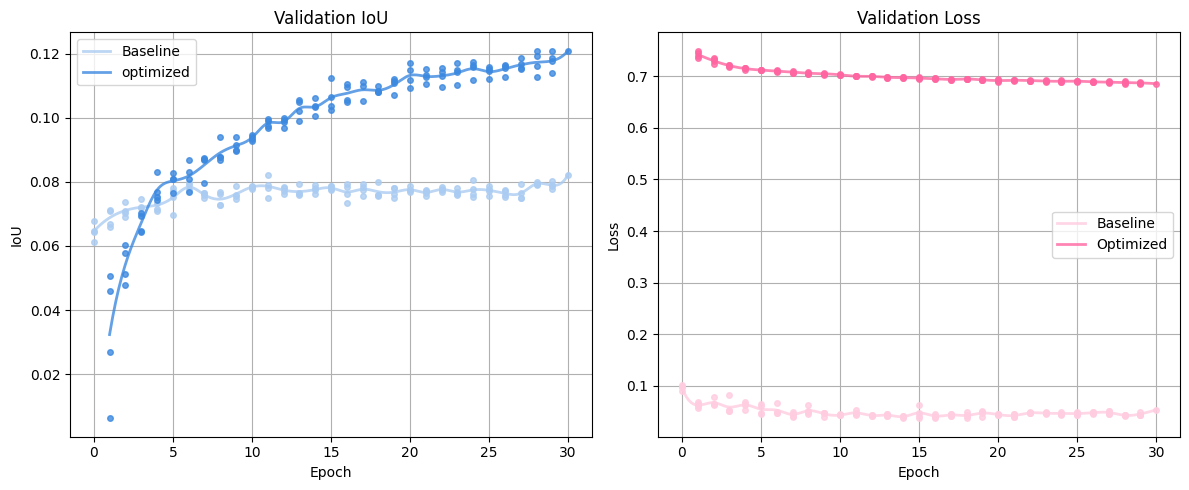

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

colors = {
    'baseline': {
        'loss': '#ffcce0',
        'iou': '#abccf2'
    },
    'optimized': {
        'loss': '#ff66a1',
        'iou': '#3c89e0'
    }
}

# CSV 로드
baseline = pd.read_csv('/Users/temp/Downloads/prj2/baseline/metrics.csv')
optimized = pd.read_csv('/Users/temp/Downloads/prj2/optimized/metrics.csv')

def clean_and_spline(x, y):
    # NaN, Inf 제거
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[mask]
    y_clean = y[mask]

    # 중복된 x 값에 대해 y 평균 계산 (pandas groupby 활용)
    df = pd.DataFrame({'x': x_clean, 'y': y_clean})
    df_grouped = df.groupby('x', as_index=False).mean()

    x_unique = df_grouped['x'].values
    y_mean = df_grouped['y'].values

    # 충분한 데이터 포인트 확인
    if len(x_unique) < 4:
        raise ValueError("Not enough unique points for spline interpolation")

    # x가 오름차순인지 확인, 아니면 정렬
    sort_idx = np.argsort(x_unique)
    x_sorted = x_unique[sort_idx]
    y_sorted = y_mean[sort_idx]

    # 스플라인 생성
    spl = make_interp_spline(x_sorted, y_sorted, k=3)

    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), 300)
    y_smooth = spl(x_smooth)

    return x_smooth, y_smooth


# iou spline
x_base, y_base = baseline['epoch'].values, baseline['val_iou'].values
x_opt, y_opt = optimized['epoch'].values, optimized['val_iou'].values
x_base_smooth, y_base_smooth = clean_and_spline(x_base, y_base)
x_opt_smooth, y_opt_smooth = clean_and_spline(x_opt, y_opt)

# loss spline
x_base_loss, y_base_loss = baseline['epoch'].values, baseline['val_loss'].values
x_opt_loss, y_opt_loss = optimized['epoch'].values, optimized['val_loss'].values
x_base_loss_smooth, y_base_loss_smooth = clean_and_spline(x_base_loss, y_base_loss)
x_opt_loss_smooth, y_opt_loss_smooth = clean_and_spline(x_opt_loss, y_opt_loss)

# 플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# IOU subplot
ax1.plot(x_base_smooth, y_base_smooth, label='Baseline', linewidth=2, color=colors['baseline']['iou'], alpha=0.8)
ax1.plot(x_base, y_base, 'o', color=colors['baseline']['iou'], markersize=4, alpha=0.8)
ax1.plot(x_opt_smooth, y_opt_smooth, label='optimized', linewidth=2, color=colors['optimized']['iou'], alpha=0.8)
ax1.plot(x_opt, y_opt, 'o', color=colors['optimized']['iou'], markersize=4, alpha=0.8)

ax1.set_title('Validation IoU')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('IoU')
ax1.legend()
ax1.grid(True)


# Loss subplot
ax2.plot(x_base_loss_smooth, y_base_loss_smooth, label='Baseline', linewidth=2, color=colors['baseline']['loss'], alpha=0.8)
ax2.plot(x_base_loss, y_base_loss, 'o', color=colors['baseline']['loss'], markersize=4, alpha=0.8)
ax2.plot(x_opt_loss_smooth, y_opt_loss_smooth, label='Optimized', linewidth=2, color=colors['optimized']['loss'], alpha=0.8)
ax2.plot(x_opt_loss, y_opt_loss, 'o', color=colors['optimized']['loss'], markersize=4, alpha=0.8)

ax2.set_title('Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
